# Semana 3 — Entrenamiento y Selección del Mejor Modelo

Clasificador de rostros de 26 futbolistas argentinos (FIFA 2022).  
Fine-tuning de modelos preentrenados en PyTorch, comparación con mAP.

| # | Sección |
|---|---|
| 1 | Setup |
| 2 | Datos |
| 3 | Métricas |
| 4 | Funciones de entrenamiento |
| **A** | FaceNet — backbone congelado (baseline) |
| **B** | EfficientNet-B2 — fine-tuning parcial |
| **C** | MobileNetV3-Large — fine-tuning end-to-end |
| 5 | Comparación y selección del ganador |
| 6 | Evaluación en test |
| 7 | Guardado del modelo |

In [2]:
# ── 1. Setup ─────────────────────────────────────────────────
import sys, subprocess, os, random, json
from pathlib import Path

# ① Instalar ANTES de tocar torch/torchvision.
#    torchmetrics: sin restricciones (no conflicto con torchvision)
#    facenet-pytorch: --no-deps para que pip NO toque la torchvision de Colab
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchmetrics"])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "facenet-pytorch"])

# ② Recién AHORA importar torch y torchvision (intactos, versión Colab)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import EfficientNet_B2_Weights, MobileNet_V3_Large_Weights

from torchmetrics.classification import (
    MulticlassAveragePrecision,
    MulticlassAccuracy,
    MulticlassF1Score,
    MulticlassConfusionMatrix
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__} | Dispositivo: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch 2.5.1+cu121 | Dispositivo: cuda
GPU: NVIDIA GeForce RTX 3070 Laptop GPU


In [3]:
import json
import os
import random
import zipfile
from pathlib import Path

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassAveragePrecision,
    MulticlassConfusionMatrix,
    MulticlassF1Score,
)
from torchvision import models, transforms
from torchvision.models import (
    EfficientNet_B2_Weights,
    MobileNet_V3_Large_Weights,
    ResNet50_Weights,
)
import warnings
warnings.filterwarnings('ignore')

In [4]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

Device: cuda
GPU   : NVIDIA GeForce RTX 3070 Laptop GPU


In [5]:
# ============================================================
# CONFIGURACIÓN GLOBAL
# ============================================================
import sys
from pathlib import Path

# ── ID del ZIP de CARAS en Google Drive (usado solo en Colab) ─────────────
# Este ZIP contiene la carpeta FIFA_2022_ONLY_FACES con las imágenes de rostros.
DRIVE_ZIP_ID = '1pG1qYiYy2p_dVOTuP2XjW2P430ykq6l-'

# ── ID del ZIP de CSVs en Google Drive (opcional, solo Colab) ────────────
# Debe contener: train.csv, val.csv, test.csv, label_to_idx.json
# Dejarlo vacío ('') si vas a correr el notebook 02 primero en Colab.
DRIVE_CSV_ZIP_ID = '1kHw9dAm5niOAEDI0wRZWhYfH7K5zEyRR'

# ── Detección de entorno ──────────────────────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # En Colab usamos /content/data como directorio base
    DATA_DIR  = '/content/data'
    FACES_DIR = '/content/data/FIFA_2022_ONLY_FACES'
else:
    # En local las rutas son relativas al directorio dev/
    DATA_DIR  = '../data'
    FACES_DIR = '../data/FIFA_2022_ONLY_FACES'

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 0
NUM_CLASSES = 26

print(f'Entorno: {"Google Colab" if IN_COLAB else "Local"}')
print(f'DATA_DIR : {DATA_DIR}')
print(f'FACES_DIR: {FACES_DIR}')


Entorno: Local
DATA_DIR : ../data
FACES_DIR: ../data/FIFA_2022_ONLY_FACES


In [6]:
# ── 2. Datos ─────────────────────────────────────────────────
import os, zipfile

os.makedirs(DATA_DIR, exist_ok=True)

# ── Descargar / verificar imágenes de caras ───────────────────────────────
if not Path(FACES_DIR).exists():
    if IN_COLAB:
        print('📥  Descargando ZIP de caras desde Google Drive...')
        try:
            import gdown
        except ImportError:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gdown', '-q'])
            import gdown
        zip_path = f'{DATA_DIR}/FIFA_2022_ONLY_FACES.zip'
        gdown.download(id=DRIVE_ZIP_ID, output=zip_path, quiet=False)
        print('📦  Extrayendo...')
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(DATA_DIR)
        os.remove(zip_path)
        print(f'✅  Caras extraídas en: {FACES_DIR}')
    else:
        print(f'❌  No se encontró el dataset en {FACES_DIR}')
        print('    Ejecuta primero el notebook 02_dataset_preparation.ipynb')
else:
    print(f'✅  Imágenes de caras encontradas en: {FACES_DIR}')

# ── Descargar / verificar CSVs ────────────────────────────────────────────
csvs_needed = ['train.csv', 'val.csv', 'test.csv', 'label_to_idx.json']
csvs_missing = [f for f in csvs_needed if not Path(f'{DATA_DIR}/{f}').exists()]

if csvs_missing:
    if IN_COLAB:
        if DRIVE_CSV_ZIP_ID:
            print(f'📥  Descargando ZIP de CSVs ({csvs_missing}) desde Drive...')
            csv_zip = f'{DATA_DIR}/csvs.zip'
            gdown.download(id=DRIVE_CSV_ZIP_ID, output=csv_zip, quiet=False)
            with zipfile.ZipFile(csv_zip, 'r') as zf:
                zf.extractall(DATA_DIR)
            os.remove(csv_zip)
            print('✅  CSVs descargados.')
        else:
            print('⚠️   Faltan archivos de split:', csvs_missing)
            print('    Opciones:')
            print('    1. Corre primero 02_dataset_preparation.ipynb en Colab')
            print('    2. Sube un ZIP con los CSVs a Drive y ponlo en DRIVE_CSV_ZIP_ID')
    else:
        print(f'❌  Faltan archivos: {csvs_missing}')
        print('    Ejecuta primero el notebook 02_dataset_preparation.ipynb')
else:
    print(f'✅  CSVs encontrados en: {DATA_DIR}')

train_df = pd.read_csv(f'{DATA_DIR}/train.csv', encoding='utf-8')
val_df   = pd.read_csv(f'{DATA_DIR}/val.csv', encoding='utf-8')
test_df  = pd.read_csv(f'{DATA_DIR}/test.csv', encoding='utf-8')

# Normalizar backslashes de Windows → forward slashes para Linux/Colab
for _df in [train_df, val_df, test_df]:
    _df['image_path'] = _df['image_path'].str.replace('\\', '/', regex=False)
with open(f'{DATA_DIR}/label_to_idx.json', encoding='utf-8') as f:
    label_to_idx = json.load(f)

idx_to_label = {v: k for k, v in label_to_idx.items()}

print(f'Train : {len(train_df)} imagenes')
print(f'Val   : {len(val_df)} imagenes')
print(f'Test  : {len(test_df)} imagenes')
print(f'Clases: {NUM_CLASSES}')


✅  Imágenes de caras encontradas en: ../data/FIFA_2022_ONLY_FACES
✅  CSVs encontrados en: ../data
Train : 630 imagenes
Val   : 210 imagenes
Test  : 210 imagenes
Clases: 26


In [7]:
class FaceDataset(Dataset):
    """
    Extiende la clase de semana 2 con dos flags adicionales:
    use_rotation y use_erasing, necesarios para el Exp C.
    """

    def __init__(self, dataframe, root_dir,
                 use_flip=False, use_color_jitter=False,
                 use_rotation=False, use_erasing=False):
        self.df       = dataframe.reset_index(drop=True)
        self.root_dir = Path(root_dir)

        steps = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
        if use_flip:
            steps.append(transforms.RandomHorizontalFlip(p=0.5))
        if use_color_jitter:
            steps.append(transforms.ColorJitter(
                brightness=0.2, contrast=0.2, saturation=0.2))
        if use_rotation:
            steps.append(transforms.RandomRotation(degrees=10))
        steps += [
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225]),
        ]
        if use_erasing:
            steps.append(transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)))

        self.transform = transforms.Compose(steps)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.root_dir / row['image_path']).convert('RGB')
        return self.transform(img), int(row['label_idx'])


def build_dataloader(df, use_flip=False, use_color_jitter=False,
                     use_rotation=False, use_erasing=False, shuffle=False):
    ds = FaceDataset(df, FACES_DIR,
                     use_flip=use_flip, use_color_jitter=use_color_jitter,
                     use_rotation=use_rotation, use_erasing=use_erasing)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=True)


## 3. Métricas — mAP en clasificación

El **mAP** que vimos en la materia es la métrica estándar de detectores de objetos:  
mide cómo el detector *rankea* sus detecciones por score de confianza a distintos umbrales de IoU.

Para clasificación multiclase aplicamos el mismo principio con una adaptación:

1. Para cada una de las 26 clases, se plantea el problema como **one-vs-rest**  
   (¿es o no es el jugador $k$?).
2. Se usa la **probabilidad softmax** como score de confianza.
3. Se calcula el **Average Precision** de cada clase = área bajo la curva precision-recall.
4. El **mAP (macro)** = promedio de los 26 AP individuales:

$$\text{mAP} = \frac{1}{26} \sum_{k=1}^{26} \text{AP}_k$$

**Ventaja sobre accuracy:** captura la calidad del *ranking* de probabilidades, no solo el top-1.  
Si el modelo asigna 0.8 a la clase correcta versus 0.51, eso se refleja en el AP.  
Además, como algunas clases tienen menos de 40 imágenes de entrenamiento, el AP por clase  
captura el rendimiento individual antes de promediar — es una métrica más justa bajo desbalance.

```python
MulticlassAveragePrecision(num_classes=26, average='macro')
```

Junto con mAP reportamos **accuracy macro** y **F1-macro** como pide la consigna.

In [8]:
# ── 4. Funciones de entrenamiento ────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

class JointEmbeddingNet(nn.Module):
    def __init__(self, backbone, embedding_dim=128, num_classes=26):
        super(JointEmbeddingNet, self).__init__()
        self.backbone = backbone
        
        if hasattr(backbone, 'last_linear'):
            # Caso FaceNet (InceptionResnetV1)
            in_features = 512
        elif hasattr(backbone, 'fc'):
            in_features = backbone.fc.in_features
            backbone.fc = nn.Identity()
        elif hasattr(backbone, 'classifier'):
            if isinstance(backbone.classifier, nn.Sequential):
                in_features = backbone.classifier[-1].in_features
                backbone.classifier[-1] = nn.Identity()
            else:
                in_features = backbone.classifier.in_features
                backbone.classifier = nn.Identity()
        else:
            in_features = 512 # Fallback
                
        self.embedding_layer = nn.Linear(in_features, embedding_dim)
        self.classifier_head = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        embeddings = self.embedding_layer(features)
        embeddings = nn.functional.normalize(embeddings, p=2, dim=1)
        logits = self.classifier_head(embeddings)
        return embeddings, logits


def batch_all_triplet_loss(embeddings, labels, margin=1.0):
    dot_product = torch.matmul(embeddings, embeddings.t())
    distances = 2.0 - 2.0 * dot_product
    distances = torch.clamp(distances, min=0.0)
    
    labels_equal = torch.eq(labels.unsqueeze(0), labels.unsqueeze(1))
    indices_not_equal = ~torch.eye(labels.size(0), dtype=torch.bool, device=embeddings.device)
    mask_anchor_positive = labels_equal & indices_not_equal
    
    mask_anchor_negative = ~labels_equal
    
    mask = mask_anchor_positive.unsqueeze(2) & mask_anchor_negative.unsqueeze(1)
    
    dist_ap = distances.unsqueeze(2)
    dist_an = distances.unsqueeze(1)
    triplet_loss = dist_ap - dist_an + margin
    
    triplet_loss = torch.clamp(triplet_loss, min=0.0)
    triplet_loss = triplet_loss * mask.float()
    
    num_active_triplets = (triplet_loss > 1e-16).float().sum()
    
    if num_active_triplets > 0:
        loss = triplet_loss.sum() / num_active_triplets
    else:
        loss = torch.tensor(0.0, device=embeddings.device)
        
    return loss


def make_metrics():
    return {
        'map': MulticlassAveragePrecision(num_classes=NUM_CLASSES, average='macro').to(DEVICE),
        'acc': MulticlassAccuracy(num_classes=NUM_CLASSES, average='macro').to(DEVICE),
        'f1' : MulticlassF1Score(num_classes=NUM_CLASSES, average='macro').to(DEVICE),
    }


def train_one_epoch_joint(model, loader, criterion_ce, optimizer, batch_scheduler=None):
    model.train()
    running_loss = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        
        embeddings, logits = model(imgs)
        
        # Perdida combinada: Clasificacion (CE) + Tripletas (Batch-All)
        loss_ce = criterion_ce(logits, labels)
        loss_triplet = batch_all_triplet_loss(embeddings, labels, margin=1.0)
        
        loss = loss_ce + loss_triplet
        loss.backward()
        optimizer.step()
        
        if batch_scheduler is not None:
            batch_scheduler.step()
        running_loss += loss.item() * imgs.size(0)
    return running_loss / len(loader.dataset)


@torch.no_grad()
def compute_class_centroids(model, loader):
    model.eval()
    embeddings_list, labels_list = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        embs, _ = model(imgs)
        embeddings_list.append(embs.cpu())
        labels_list.append(labels)
        
    embeddings = torch.cat(embeddings_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    
    centroids = []
    for c in range(NUM_CLASSES):
        class_embs = embeddings[labels == c]
        if len(class_embs) > 0:
            mean_emb = class_embs.mean(dim=0)
            mean_emb = nn.functional.normalize(mean_emb, p=2, dim=0)
            centroids.append(mean_emb)
        else:
            centroids.append(torch.zeros(embeddings.shape[1]))
            
    return torch.stack(centroids, dim=0).to(DEVICE)


@torch.no_grad()
def evaluate_triplet(model, loader, centroids_tensor, metrics):
    model.eval()
    for m in metrics.values():
        m.reset()
    running_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        embeddings, _ = model(imgs)
        
        similarities = torch.matmul(embeddings, centroids_tensor.t())
        logits = similarities * 10.0
        loss = criterion(logits, labels)
        running_loss += loss.item() * imgs.size(0)
        
        probs = torch.softmax(logits, dim=1)
        for m in metrics.values():
            m.update(probs, labels)
            
    return running_loss / len(loader.dataset), {k: m.compute().item() for k, m in metrics.items()}


def run_experiment(name, model, train_loader, train_eval_loader, val_loader, criterion, optimizer, n_epochs,
                   epoch_scheduler=None, batch_scheduler=None, scheduler_metric='map'):
    metrics  = make_metrics()
    history  = {'train_loss': [], 'val_loss': [], 'val_map': [], 'val_acc': [], 'val_f1': []}
    best_map = 0.0
    best_wts = None

    for epoch in range(1, n_epochs + 1):
        train_loss      = train_one_epoch_joint(model, train_loader, criterion, optimizer, batch_scheduler)
        centroids_tensor = compute_class_centroids(model, train_eval_loader)
        val_loss, val_m = evaluate_triplet(model, val_loader, centroids_tensor, metrics)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_map'].append(val_m['map'])
        history['val_acc'].append(val_m['acc'])
        history['val_f1'].append(val_m['f1'])

        if epoch_scheduler is not None:
            if isinstance(epoch_scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                epoch_scheduler.step(val_m[scheduler_metric])
            else:
                epoch_scheduler.step()

        if val_m['map'] > best_map:
            best_map = val_m['map']
            best_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # Imprimir en cada epoca para ver el progreso en tiempo real en la consola local
        print(f'[{name}] Ep {epoch:02d}/{n_epochs} | '
              f'Loss tr={train_loss:.4f} val={val_loss:.4f} | '
              f"mAP={val_m['map']:.4f} Acc={val_m['acc']:.4f} F1={val_m['f1']:.4f}")

    model.load_state_dict(best_wts)
    return model, history, best_map


def plot_curves(history, name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(history['train_loss'], label='train')
    ax1.plot(history['val_loss'],   label='val', linestyle='--')
    ax1.set_title(f'{name} — Perdida')
    ax1.set_xlabel('Epoca')
    ax1.legend()
    ax1.grid(alpha=0.3)

    ax2.plot(history['val_map'], label='mAP')
    ax2.plot(history['val_acc'], label='Accuracy')
    ax2.plot(history['val_f1'],  label='F1-macro')
    ax2.set_title(f'{name} — Metricas (val)')
    ax2.set_xlabel('Epoca')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle(name, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def plot_latent_space(model, loader, idx_to_label):
    model.eval()
    embeddings = []
    labels = []
    
    for imgs, lbls in loader:
        imgs = imgs.to(DEVICE)
        embs, _ = model(imgs)
        embeddings.append(embs.cpu().numpy())
        labels.append(lbls.numpy())
        
    embeddings = np.concatenate(embeddings, axis=0)
    labels = np.concatenate(labels, axis=0)
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)//2))
    embeddings_2d = tsne.fit_transform(embeddings)
    
    plt.figure(figsize=(11, 9), dpi=120)
    unique_labels = np.unique(labels)
    # Usar un colormap cualitativo y variado para distinguir las 26 clases
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
    
    for idx, label_idx in enumerate(unique_labels):
        mask = labels == label_idx
        plt.scatter(
            embeddings_2d[mask, 0], 
            embeddings_2d[mask, 1], 
            color=colors[idx % len(colors)],
            label=idx_to_label[label_idx].replace('_', ' ').split()[-1],
            alpha=0.85,
            edgecolors='none',
            s=40
        )
        
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=2, fontsize=8, frameon=True, facecolor='whitesmoke')
    plt.title("Visualización del Espacio Latente (t-SNE 2D)", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Componente t-SNE 1", fontsize=10)
    plt.ylabel("Componente t-SNE 2", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


# Experimento A — FaceNet (InceptionResnetV1) | Solo cabeza (baseline)

### Por qué FaceNet (InceptionResnetV1)

FaceNet es el punto de partida ideal para problemas de reconocimiento facial porque:
- Es una arquitectura especializada en el dominio de rostros, preentrenada en el dataset gigante **VGGFace2**.
- Sus capas intermedias ya han aprendido a reconocer micro-estructuras faciales (distancia interocular, forma de la nariz, contorno de la cara), a diferencia de ResNet que se preentrenó en imágenes genéricas de ImageNet (perros, coches, árboles).
- Proporciona un espacio latente de embeddings de 512 dimensiones muy robusto y optimizado para la similitud de rostros.

### Por qué congelar todo el backbone

El backbone de FaceNet tiene **23.5 millones de parámetros**. Al congelar el backbone y entrenar únicamente la cabeza de proyección lineal (`embedding_layer`: 512 → 128) y el cabezal de clasificación auxiliar (`classifier_head`: 128 → 26), reducimos los parámetros entrenables a **~70,000 parámetros**.

Este experimento responde a la pregunta clave:  
*¿son los pesos faciales preentrenados de FaceNet suficientes para separar y clasificar a nuestros 26 jugadores con muy pocas imágenes?*

### Por qué sin augmentaciones

Intencionalmente no se usan augmentaciones en train para **aislar el efecto de la estrategia  
de fine-tuning** del efecto de la augmentación. Esto hace la comparación A vs. B vs. C más limpia.

### Por qué Adam + ReduceLROnPlateau

Con pocos parámetros entrenables (solo la cabeza), Adam converge muy rápido.  
`ReduceLROnPlateau(patience=3)` divide el LR a la mitad cuando el mAP en validación  
no mejora en 3 épocas consecutivas, evitando que el optimizer oscile alrededor del mínimo.

In [9]:
set_seed()

from facenet_pytorch import InceptionResnetV1

# ── Modelo (FaceNet SOTA preentrenado en caras) ────────────────
facenet = InceptionResnetV1(pretrained='vggface2')

# Congelar backbone para entrenamiento baseline de cabeza
for param in facenet.parameters():
    param.requires_grad = False

model_a = JointEmbeddingNet(facenet, embedding_dim=128, num_classes=NUM_CLASSES)
model_a = model_a.to(DEVICE)

n_train = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model_a.parameters())
print(f'Parametros entrenables: {n_train:,} / {n_total:,}')

# ── DataLoaders ──────────────────────────────────────────────
train_loader_a = build_dataloader(train_df, shuffle=True)
train_eval_loader_a = build_dataloader(train_df, shuffle=False)
val_loader_a   = build_dataloader(val_df)

# ── Loss / Optimizer / Scheduler ────────────────────────────
criterion_a = nn.CrossEntropyLoss()
optimizer_a = torch.optim.Adam(
    list(model_a.embedding_layer.parameters()) + list(model_a.classifier_head.parameters()), 
    lr=1e-3
)
scheduler_a = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_a, mode='max', patience=3, factor=0.5
)

# ── Entrenamiento (25 epocas completas) ─────────────────────────────
model_a, history_a, best_map_a = run_experiment(
    'Exp A',
    model_a, train_loader_a, train_eval_loader_a, val_loader_a,
    criterion_a, optimizer_a, n_epochs=25,
    epoch_scheduler=scheduler_a, scheduler_metric='map',
)
print(f'\nMejor mAP validacion Exp A: {best_map_a:.4f}')


Parametros entrenables: 69,018 / 27,979,345
[Exp A] Ep 01/25 | Loss tr=4.0428 val=2.1764 | mAP=0.5013 Acc=0.4531 F1=0.4470
[Exp A] Ep 02/25 | Loss tr=3.9145 val=2.5550 | mAP=0.4373 Acc=0.3955 F1=0.3841
[Exp A] Ep 03/25 | Loss tr=3.8891 val=2.7132 | mAP=0.4058 Acc=0.3759 F1=0.3626
[Exp A] Ep 04/25 | Loss tr=3.7974 val=2.6346 | mAP=0.4211 Acc=0.3682 F1=0.3654
[Exp A] Ep 05/25 | Loss tr=3.7533 val=2.4617 | mAP=0.4617 Acc=0.4241 F1=0.4098
[Exp A] Ep 06/25 | Loss tr=3.6545 val=2.4344 | mAP=0.4637 Acc=0.4248 F1=0.4158
[Exp A] Ep 07/25 | Loss tr=3.6571 val=2.4859 | mAP=0.4646 Acc=0.4193 F1=0.4115
[Exp A] Ep 08/25 | Loss tr=3.5761 val=2.5311 | mAP=0.4577 Acc=0.4198 F1=0.4166
[Exp A] Ep 09/25 | Loss tr=3.5210 val=2.5584 | mAP=0.4382 Acc=0.4262 F1=0.4210
[Exp A] Ep 10/25 | Loss tr=3.5333 val=2.5332 | mAP=0.4472 Acc=0.4118 F1=0.4130
[Exp A] Ep 11/25 | Loss tr=3.4975 val=2.4641 | mAP=0.4601 Acc=0.4155 F1=0.4165
[Exp A] Ep 12/25 | Loss tr=3.4970 val=2.4455 | mAP=0.4576 Acc=0.4313 F1=0.4278
[Exp A] 

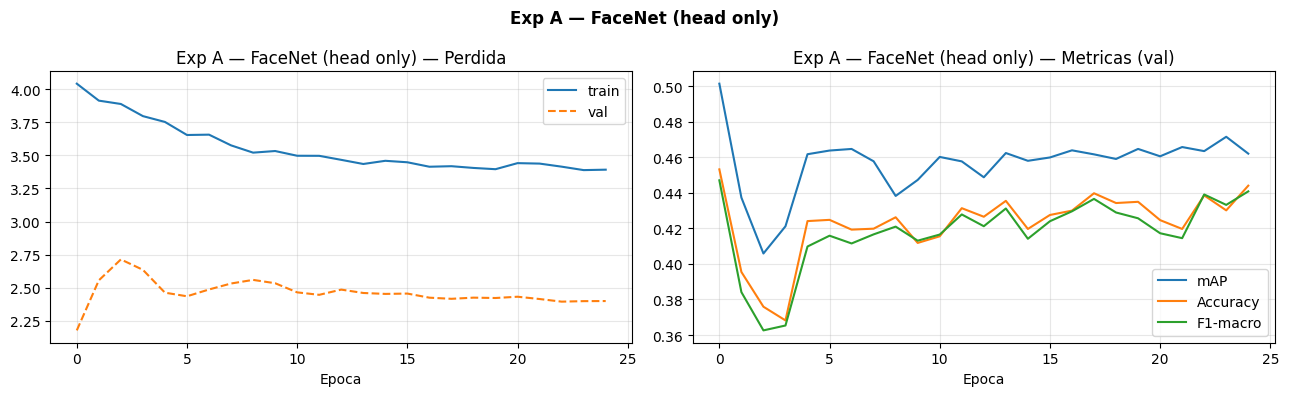

In [10]:
plot_curves(history_a, 'Exp A — FaceNet (head only)')


---
## Experimento B — EfficientNet-B2 | Fine-tuning parcial

### Por qué EfficientNet-B2

EfficientNet aplica **compound scaling**: escala simultáneamente profundidad, ancho y resolución  
con un coeficiente único. Esto produce mejor relación accuracy/parámetros que FaceNet.

EfficientNet-B2 específicamente:
- **9M parámetros** vs. 25M de FaceNet → 3× más compacto, `~36 MB` como `.pth`  
  (debajo del límite de GitHub sin necesidad de Git LFS).
- Accuracy en ImageNet comparable a FaceNet con menos parámetros → regularización implícita mayor.

### Por qué congelar los primeros 5 bloques y descongelar los últimos 3

En EfficientNet, `features[0..4]` captura edges, texturas, colores y formas simples —  
features universales que transfieren bien a cualquier dominio visual.  
`features[5..8]` captura semántica de alto nivel (específica de las 1000 clases de ImageNet)  
y necesita adaptación para distinguir 26 caras de futbolistas.

Esta división sigue la heurística de *descongelar desde arriba hacia abajo* y equilibra:
- **Adaptación**: features de alto nivel deben aprender a separar estas 26 caras.
- **Estabilidad**: descongelar todo con ~28 imágenes/clase en train causaría olvido catastrófico.

### Por qué learning rates diferenciales (AdamW)

Si aplicamos el mismo LR a capas preentrenadas y a la nueva cabeza, hay una tensión:  
la cabeza necesita un LR alto para aprender desde cero, pero los bloques preentrenados  
se destruirían con ese mismo LR.

La solución es **discriminative fine-tuning** (Howard & Ruder, ULMFiT 2018):
- `backbone_params`: `lr = 5e-5` (10× más lento que la cabeza).
- `head_params`: `lr = 5e-4`.

AdamW agrega la penalización L2 directamente sobre los pesos  
(no sobre el gradiente como Adam) → mejor regularización durante fine-tuning.

### Por qué label_smoothing = 0.1

Con ~28 imágenes/clase en train, el modelo tiende a ser sobreconfiante  
(probabilidad cercana a 1.0 para la clase correcta). Esto degrada el mAP:  
la curva precision-recall se "aplana" en valores altos de confianza.  
`label_smoothing=0.1` distribuye 10% de la masa de probabilidad a las otras 25 clases  
→ mejor calibración → mejora directa en mAP.

### Por qué CosineAnnealingLR

Baja el LR siguiendo una curva coseno desde `lr_max` hasta ~0 en `T_max=30` épocas,  
sin discontinuidades como el step decay. Complementa bien AdamW porque la penalización L2  
y la reducción suave del LR actúan juntas como regularización.

In [11]:
set_seed()

# ── Modelo ──────────────────────────────────────────────────
efficientnet = models.efficientnet_b2(weights=EfficientNet_B2_Weights.IMAGENET1K_V1)

# Congelar primeros 5 bloques (stem + MBConv iniciales)
for i, block in enumerate(efficientnet.features):
    if i < 5:
        for param in block.parameters():
            param.requires_grad = False

model_b = JointEmbeddingNet(efficientnet, embedding_dim=128, num_classes=NUM_CLASSES)
model_b = model_b.to(DEVICE)

n_train = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model_b.parameters())
print(f'Parametros entrenables: {n_train:,} / {n_total:,}')

# ── DataLoaders ──────────────────────────────────────────────
train_loader_b = build_dataloader(train_df, use_flip=True, use_color_jitter=True, shuffle=True)
train_eval_loader_b = build_dataloader(train_df, shuffle=False)
val_loader_b   = build_dataloader(val_df)

# ── Grupos de parametros con LR diferencial ──────────────────
backbone_params_b = [
    p for name, p in model_b.backbone.named_parameters()
    if p.requires_grad
]
head_params_b = list(model_b.embedding_layer.parameters()) + list(model_b.classifier_head.parameters())

criterion_b = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_b = torch.optim.AdamW([
    {'params': backbone_params_b, 'lr': 5e-5, 'weight_decay': 1e-4},
    {'params': head_params_b,     'lr': 5e-4, 'weight_decay': 1e-4},
])
scheduler_b = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_b, T_max=30)

# ── Entrenamiento (30 epocas completas) ─────────────────────────────
model_b, history_b, best_map_b = run_experiment(
    'Exp B',
    model_b, train_loader_b, train_eval_loader_b, val_loader_b,
    criterion_b, optimizer_b, n_epochs=30,
    epoch_scheduler=scheduler_b,
)
print(f'\nMejor mAP validacion Exp B: {best_map_b:.4f}')


Parametros entrenables: 7,329,604 / 7,884,700
[Exp B] Ep 01/30 | Loss tr=4.2552 val=3.1569 | mAP=0.1248 Acc=0.1238 F1=0.1179
[Exp B] Ep 02/30 | Loss tr=4.2429 val=3.2368 | mAP=0.1051 Acc=0.0986 F1=0.0852
[Exp B] Ep 03/30 | Loss tr=4.1984 val=3.4476 | mAP=0.1128 Acc=0.0767 F1=0.0674
[Exp B] Ep 04/30 | Loss tr=4.1805 val=3.8409 | mAP=0.1148 Acc=0.0927 F1=0.0807
[Exp B] Ep 05/30 | Loss tr=4.1780 val=3.8146 | mAP=0.1260 Acc=0.1201 F1=0.1047
[Exp B] Ep 06/30 | Loss tr=4.1427 val=4.1994 | mAP=0.1214 Acc=0.1033 F1=0.0852
[Exp B] Ep 07/30 | Loss tr=4.1295 val=4.1596 | mAP=0.1306 Acc=0.1069 F1=0.0891
[Exp B] Ep 08/30 | Loss tr=4.0798 val=4.2485 | mAP=0.1427 Acc=0.1276 F1=0.1214
[Exp B] Ep 09/30 | Loss tr=4.0533 val=4.0870 | mAP=0.1524 Acc=0.1468 F1=0.1301
[Exp B] Ep 10/30 | Loss tr=4.0177 val=4.1689 | mAP=0.1639 Acc=0.1348 F1=0.1264
[Exp B] Ep 11/30 | Loss tr=3.9491 val=4.3861 | mAP=0.1564 Acc=0.1335 F1=0.1241
[Exp B] Ep 12/30 | Loss tr=3.9726 val=4.5260 | mAP=0.1588 Acc=0.1523 F1=0.1428
[Exp B

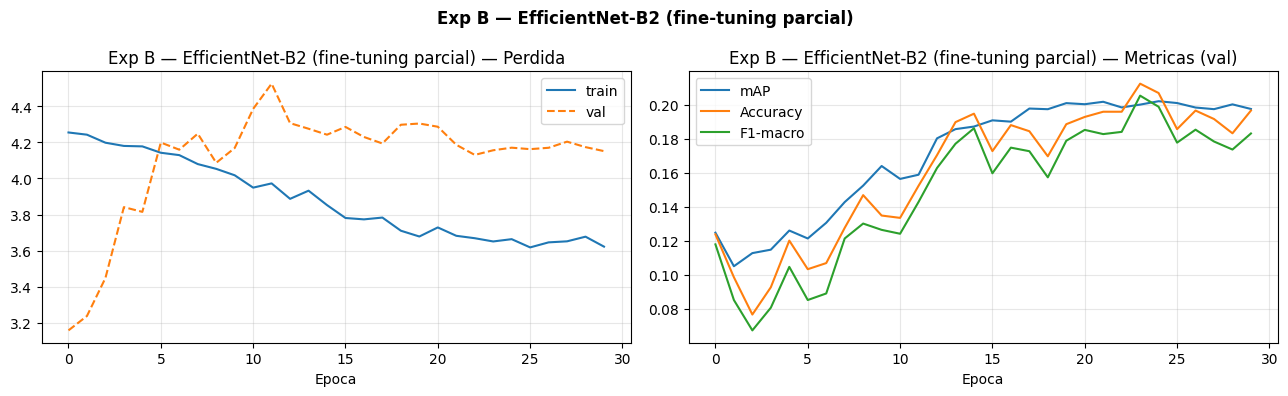

In [12]:
plot_curves(history_b, 'Exp B — EfficientNet-B2 (fine-tuning parcial)')

---
## Experimento C — MobileNetV3-Large | Fine-tuning end-to-end

### Por qué MobileNetV3-Large

MobileNetV3-Large fue diseñado para **inferencia eficiente en dispositivos con recursos limitados**.  
Sus características clave son:
- **Inverted residuals + squeeze-and-excitation**: mejoran la capacidad semántica sin aumentar el costo computacional.
- **Hard-Swish activation**: aproximación eficiente de Swish, más rápida en hardware real.
- **5.4M parámetros, ~22 MB como `.pth`**: el modelo más liviano de los tres.

El tamaño es el factor decisivo para la **Semana 4 (despliegue en Streamlit Cloud)**:  
la plataforma tiene ~1 GB de RAM y límites de carga. Con 22 MB el modelo se carga en segundos  
y no requiere Git LFS. FaceNet (~100 MB) y EfficientNet-B2 (~36 MB) son alternativas válidas  
pero MobileNet favorece el despliegue sin fricciones.

### Por qué fine-tuning end-to-end

Exp A y B testean estrategias conservadoras. Exp C testa el extremo opuesto:  
*¿puede el fine-tuning completo superarlos si se regula correctamente?*

El riesgo principal es el **olvido catastrófico**: actualizaciones agresivas en los  
primeros pasos destruyen los pesos preentrenados. Se mitiga con tres mecanismos:

1. **OneCycleLR con warmup (30% de los pasos)**: el LR empieza muy bajo, sube gradualmente  
   hasta `max_lr` y luego baja. La fase de warmup evita updates grandes cuando los gradientes  
   son ruidosos al inicio.
2. **SGD + momentum + weight decay**: SGD no adapta el LR por parámetro → converge más lento  
   pero generaliza mejor en datasets pequeños (Kornblith et al. 2019).
3. **Dropout aumentado**: el clasificador original de MobileNet tiene `Dropout(0.2)`;  
   lo subimos a `Dropout(0.3)` para añadir regularización extra al entrenar todo end-to-end.

### Por qué augmentaciones más agresivas

Con end-to-end fine-tuning el modelo tiene más capacidad para memorizar el set de entrenamiento.  
Se agregan dos augmentaciones sobre las ya usadas en B:

- **RandomRotation(±10°)**: las fotos de jugadores no siempre están perfectamente alineadas  
  (tiro de cabeza, festejo). Rotaciones pequeñas dan invarianza a inclinaciones de la cabeza.
- **RandomErasing(p=0.2, scale=(0.02, 0.15))**: enmascara regiones pequeñas de la cara,  
  simulando oclusiones parciales (pelo sobre los ojos, manos, cascos).  
  Obliga al modelo a no depender de ninguna región específica.  
  Se aplica **después de `ToTensor`** para que las regiones enmascaradas queden en valor 0  
  (que equivale a la media de normalización).

### Por qué OneCycleLR en lugar de los schedulers de A y B

`OneCycleLR` implementa **super-convergence** (Smith & Topin 2018): un LR que sube y baja  
en un único ciclo puede converger más rápido y llegar a mejores mínimos que cualquier LR fijo.  
El warmup actúa como búsqueda del LR óptimo en las primeras épocas.

**Atención técnica**: `OneCycleLR` debe avanzarse **por batch**, no por época.  
Se pasa como `batch_scheduler` a `run_experiment`, que lo llama dentro de `train_one_epoch`.

In [13]:
set_seed()

# ── Modelo ──────────────────────────────────────────────────
mobilenet = models.mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V2)
# Aumentar dropout del clasificador original (0.2 → 0.3)
mobilenet.classifier[2] = nn.Dropout(p=0.3)

model_c = JointEmbeddingNet(mobilenet, embedding_dim=128, num_classes=NUM_CLASSES)
model_c = model_c.to(DEVICE)

n_train = sum(p.numel() for p in model_c.parameters() if p.requires_grad)
print(f'Parametros entrenables: {n_train:,} (todos — end-to-end)')

# ── DataLoaders (augmentaciones mas agresivas) ───────────────
train_loader_c = build_dataloader(
    train_df,
    use_flip=True, use_color_jitter=True,
    use_rotation=True, use_erasing=True,
    shuffle=True,
)
train_eval_loader_c = build_dataloader(train_df, shuffle=False)
val_loader_c = build_dataloader(val_df)

# ── Loss / Optimizer / Scheduler ────────────────────────────
criterion_c = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_c = torch.optim.SGD(
    model_c.parameters(), lr=5e-3, momentum=0.9, weight_decay=5e-4
)
# OneCycleLR avanza por batch → steps_per_epoch = len(train_loader)
scheduler_c = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_c,
    max_lr=5e-3,
    epochs=40,
    steps_per_epoch=len(train_loader_c),
    pct_start=0.3,         # 30% del tiempo en fase de warmup
    anneal_strategy='cos', # annealing coseno
)

# ── Entrenamiento (40 epocas completas) ─────────────────────────────
model_c, history_c, best_map_c = run_experiment(
    'Exp C',
    model_c, train_loader_c, train_eval_loader_c, val_loader_c,
    criterion_c, optimizer_c, n_epochs=40,
    batch_scheduler=scheduler_c,   # OneCycleLR por batch
)
print(f'\nMejor mAP validacion Exp C: {best_map_c:.4f}')


Parametros entrenables: 4,369,354 (todos — end-to-end)
[Exp C] Ep 01/40 | Loss tr=4.2532 val=3.0567 | mAP=0.2027 Acc=0.2292 F1=0.2117
[Exp C] Ep 02/40 | Loss tr=4.2509 val=3.0191 | mAP=0.2137 Acc=0.2134 F1=0.2087
[Exp C] Ep 03/40 | Loss tr=4.2488 val=2.9976 | mAP=0.2051 Acc=0.1998 F1=0.1971
[Exp C] Ep 04/40 | Loss tr=4.2336 val=3.0610 | mAP=0.1677 Acc=0.1638 F1=0.1636
[Exp C] Ep 05/40 | Loss tr=4.2316 val=3.0811 | mAP=0.1797 Acc=0.1431 F1=0.1331
[Exp C] Ep 06/40 | Loss tr=4.2030 val=3.1967 | mAP=0.1529 Acc=0.1443 F1=0.1231
[Exp C] Ep 07/40 | Loss tr=4.2453 val=3.2245 | mAP=0.1828 Acc=0.1232 F1=0.1177
[Exp C] Ep 08/40 | Loss tr=4.2148 val=3.0826 | mAP=0.1770 Acc=0.1467 F1=0.1372
[Exp C] Ep 09/40 | Loss tr=4.2183 val=3.2200 | mAP=0.1503 Acc=0.1398 F1=0.1293
[Exp C] Ep 10/40 | Loss tr=4.2099 val=3.1780 | mAP=0.1556 Acc=0.1500 F1=0.1365
[Exp C] Ep 11/40 | Loss tr=4.2074 val=3.0377 | mAP=0.1653 Acc=0.1462 F1=0.1320
[Exp C] Ep 12/40 | Loss tr=4.1628 val=3.1127 | mAP=0.1444 Acc=0.1493 F1=0.13

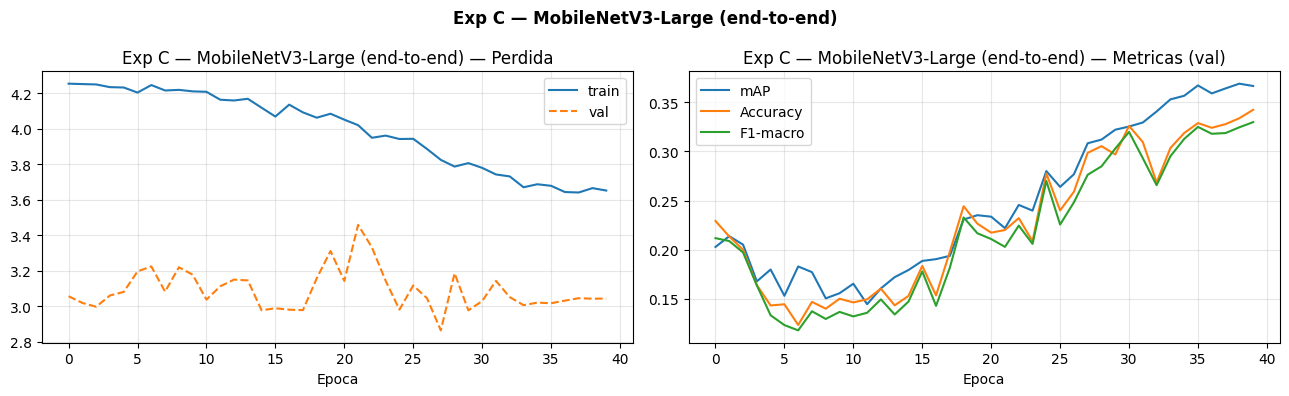

In [14]:
plot_curves(history_c, 'Exp C — MobileNetV3-Large (end-to-end)')

---
## 5. Comparación de los 3 experimentos

La tabla muestra los mejores valores en **validación**.  
El modelo ganador se evaluará sobre **test** en la sección siguiente  
(el conjunto de test no se toca hasta este punto).

In [15]:
results_df = pd.DataFrame({
    'Experimento':        ['A — FaceNet (head)', 'B — EfficientNet-B2 (parcial)', 'C — MobileNetV3 (e2e)'],
    'Capas descongeladas':['Solo head (~70K)',     'Ultimos 3 bloques + head (~3.4M)', 'Todas (~5.4M)'],
    'Augmentaciones':     ['Ninguna',              'Flip + ColorJitter',               'Flip + CJ + Rotation + Erasing'],
    'Optimizer':          ['Adam',                 'AdamW (lr diferencial)',            'SGD + OneCycleLR'],
    'Label smoothing':    ['No',                   '0.1',                              '0.1'],
    'mAP (val)':          [round(best_map_a, 4),   round(best_map_b, 4),               round(best_map_c, 4)],
    'Acc (val)':          [round(max(history_a['val_acc']), 4),
                           round(max(history_b['val_acc']), 4),
                           round(max(history_c['val_acc']), 4)],
    'F1 (val)':           [round(max(history_a['val_f1']), 4),
                           round(max(history_b['val_f1']), 4),
                           round(max(history_c['val_f1']), 4)],
    'Tamano .pth':        ['~90 MB', '~36 MB', '~22 MB'],
})

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print(results_df.to_string(index=False))


                  Experimento              Capas descongeladas                 Augmentaciones              Optimizer Label smoothing  mAP (val)  Acc (val)  F1 (val) Tamano .pth
           A — FaceNet (head)                 Solo head (~70K)                        Ninguna                   Adam              No     0.5013     0.4531    0.4470      ~90 MB
B — EfficientNet-B2 (parcial) Ultimos 3 bloques + head (~3.4M)             Flip + ColorJitter AdamW (lr diferencial)             0.1     0.2020     0.2123    0.2053      ~36 MB
        C — MobileNetV3 (e2e)                    Todas (~5.4M) Flip + CJ + Rotation + Erasing       SGD + OneCycleLR             0.1     0.3691     0.3424    0.3299      ~22 MB


### Selección del ganador

El modelo ganador se selecciona por **mayor mAP en validación**.  
Si dos modelos están a menos de 0.01 de mAP, el desempate lo gana el más liviano  
(favorece el despliegue en Semana 4).

La evaluación final se realiza **únicamente sobre test**, que no se usó en ningún momento  
durante el entrenamiento ni la selección de hiperparámetros.

In [16]:
# ── 6. Evaluacion final en test ──────────────────────────────

candidates = [
    ('A — FaceNet',         model_a, best_map_a),
    ('B — EfficientNet-B2', model_b, best_map_b),
    ('C — MobileNetV3',     model_c, best_map_c),
]
best_name, best_model, best_val_map = max(candidates, key=lambda x: x[2])
print(f'Modelo seleccionado: {best_name}')
print(f'mAP en validacion  : {best_val_map:.4f}')

train_eval_loader = build_dataloader(train_df, shuffle=False)
best_centroids = compute_class_centroids(best_model, train_eval_loader)

test_loader  = build_dataloader(test_df)
test_metrics = make_metrics()
_, test_m    = evaluate_triplet(best_model, test_loader, best_centroids, test_metrics)

print(f"\n{'='*45}")
print(f'  Metricas finales en TEST — {best_name}')
print(f"{'='*45}")
print(f"  mAP (macro)  : {test_m['map']:.4f}")
print(f"  Accuracy     : {test_m['acc']:.4f}")
print(f"  F1 (macro)   : {test_m['f1']:.4f}")
print(f"{'='*45}")


Modelo seleccionado: A — FaceNet
mAP en validacion  : 0.5013

  Metricas finales en TEST — A — FaceNet
  mAP (macro)  : 0.5819
  Accuracy     : 0.5197
  F1 (macro)   : 0.5094


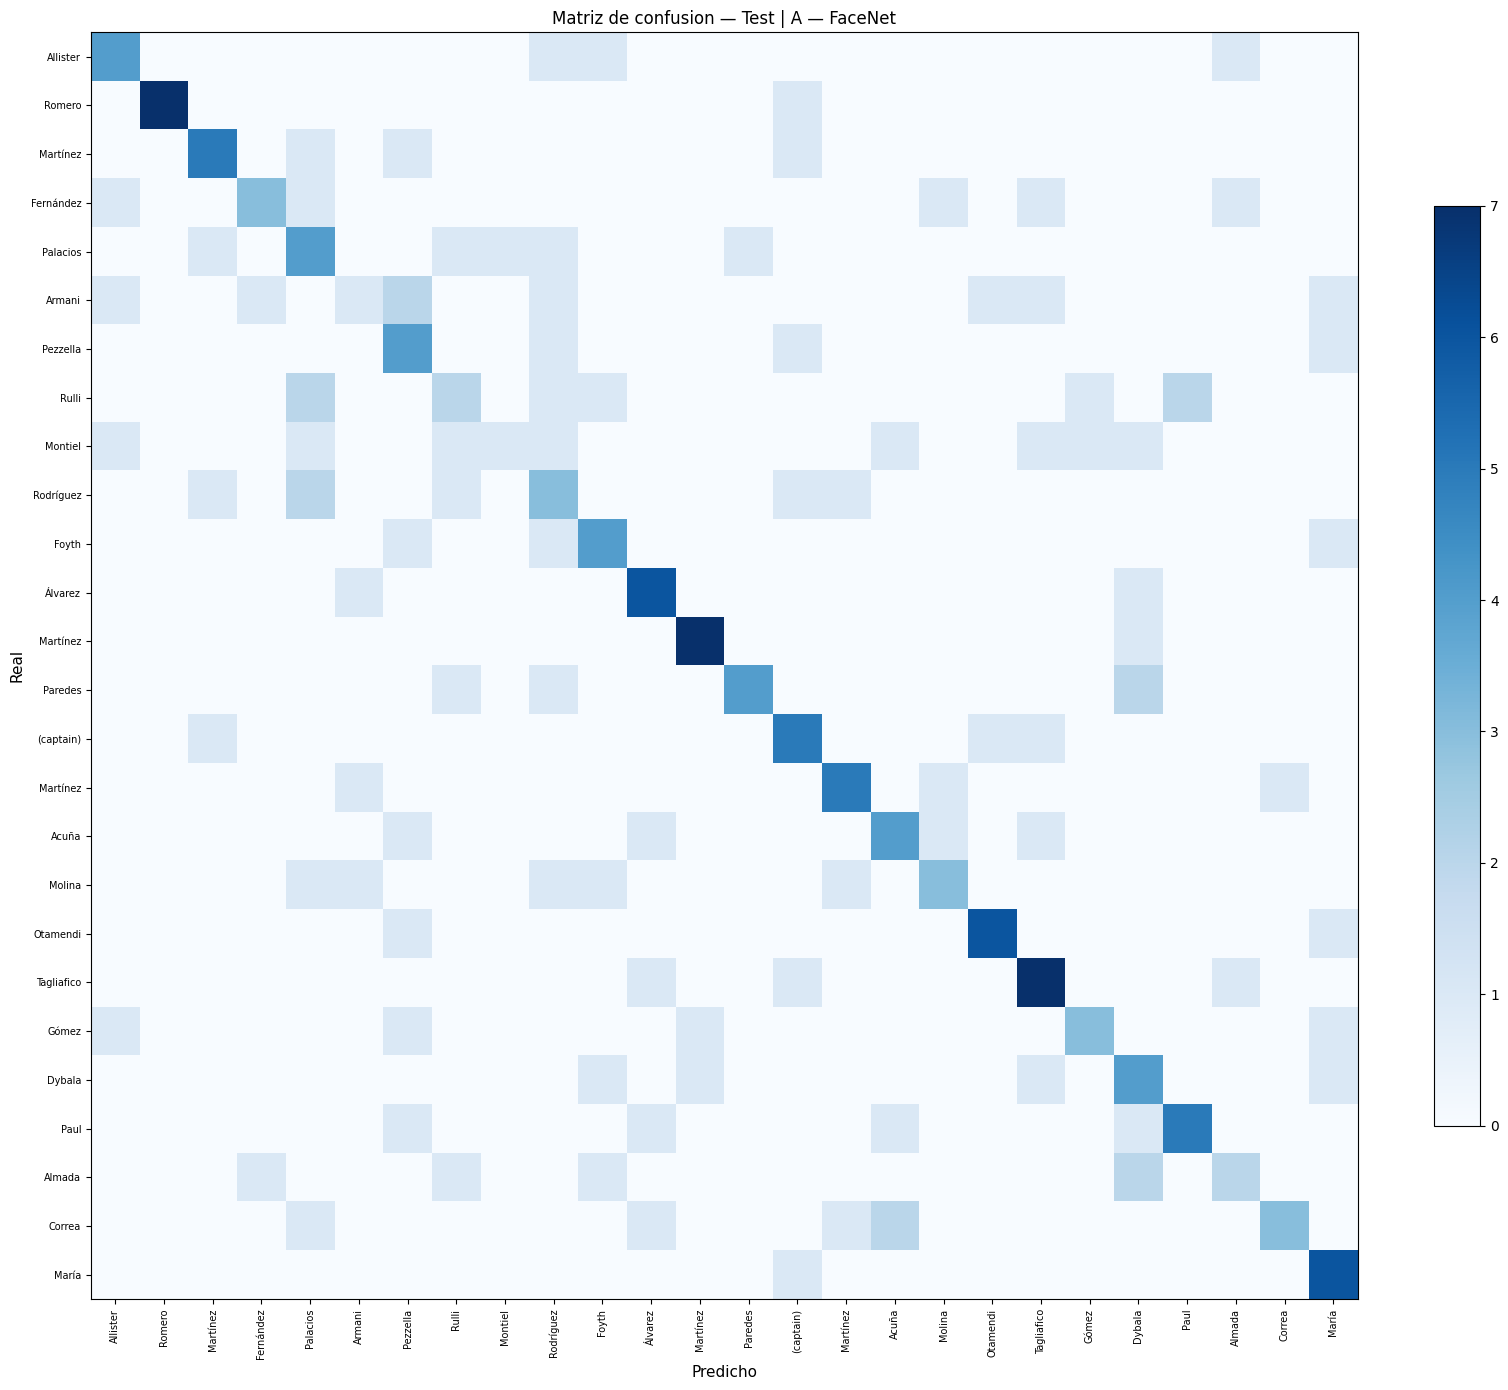


Peores 5 clases (accuracy por clase):
  Franco Armani                  11.11%
  Gonzalo Montiel                11.11%
  Gerónimo Rulli                 22.22%
  Thiago Almada                  28.57%
  Guido Rodríguez                33.33%


In [17]:
# ── Matriz de confusion ──────────────────────────────────────

cm_metric    = MulticlassConfusionMatrix(num_classes=NUM_CLASSES).to(DEVICE)
all_preds    = []
all_true     = []

best_model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        embeddings, _ = best_model(imgs)
        similarities = torch.matmul(embeddings, best_centroids.t())
        logits = similarities * 10.0
        cm_metric.update(torch.softmax(logits, 1), labels)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_true.extend(labels.cpu().numpy())

cm          = cm_metric.compute().cpu().numpy()
class_names = [idx_to_label[i].replace('_', ' ').split()[-1] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(class_names, rotation=90, fontsize=7)
ax.set_yticklabels(class_names, fontsize=7)
ax.set_xlabel('Predicho', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
ax.set_title(f'Matriz de confusion — Test | {best_name}', fontsize=12)
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

# Peores 5 clases
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
worst_5 = sorted(enumerate(per_class_acc), key=lambda x: x[1])[:5]
print('\nPeores 5 clases (accuracy por clase):')
for idx, acc in worst_5:
    print(f'  {idx_to_label[idx]:<30} {acc:.2%}')


---
## 7. Refinamiento del Modelo Ganador

Una vez elegido el mejor modelo de los tres experimentos, lo sometemos a una batería de
**tres estrategias de refinamiento** para intentar exprimir el máximo rendimiento:

| # | Estrategia | Qué hace |
|---|-----------|---------|
| R1 | **Fine-tuning profundo** | Descongela las últimas capas del backbone y re-entrena 15 épocas con LR diferencial (backbone 1e-5, cabeza 1e-4) + cosine annealing. |
| R2 | **Test-Time Augmentation (TTA)** | Sin re-entrenar: promedia las predicciones sobre 5 versiones aumentadas de cada imagen de test. |
| R3 | **Ensemble top-2** | Promedia las similitudes de coseno del ganador y el segundo mejor modelo. |

Al final se comparan los mAP en **validación** (para no contaminar el test) y el refinamiento ganador
se evalúa definitivamente en el conjunto de **test**.


In [18]:
import copy

# ── R1: Fine-tuning profundo sobre el backbone del ganador ────────────────
print("=" * 55)
print("  R1 — Fine-tuning profundo (backbone descongelado)")
print("=" * 55)

model_r1 = copy.deepcopy(best_model)

# Descongelar TODOS los parámetros del backbone
for param in model_r1.backbone.parameters():
    param.requires_grad = True

n_train = sum(p.numel() for p in model_r1.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model_r1.parameters())
print(f"Parámetros entrenables: {n_train:,} / {n_total:,}")

# DataLoaders con augmentations moderadas para el fine-tuning
train_loader_r1 = build_dataloader(
    train_df, use_flip=True, use_color_jitter=True, shuffle=True
)
train_eval_loader_r1 = build_dataloader(train_df, shuffle=False)
val_loader_r1 = build_dataloader(val_df)

# LR diferencial: backbone muy bajo para no destruir los pesos preentrenados,
# cabeza un poco más alto para adaptarse al dataset de jugadores
backbone_params_r1 = [p for p in model_r1.backbone.parameters() if p.requires_grad]
head_params_r1 = (
    list(model_r1.embedding_layer.parameters()) +
    list(model_r1.classifier_head.parameters())
)

criterion_r1 = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer_r1 = torch.optim.AdamW([
    {'params': backbone_params_r1, 'lr': 1e-5, 'weight_decay': 1e-4},
    {'params': head_params_r1,     'lr': 1e-4, 'weight_decay': 1e-4},
])
scheduler_r1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_r1, T_max=15)

model_r1, history_r1, best_map_r1 = run_experiment(
    'R1-FineTune', model_r1,
    train_loader_r1, train_eval_loader_r1, val_loader_r1,
    criterion_r1, optimizer_r1, n_epochs=15,
    epoch_scheduler=scheduler_r1,
)
print(f"\nMejor mAP validación R1: {best_map_r1:.4f}")


  R1 — Fine-tuning profundo (backbone descongelado)
Parámetros entrenables: 27,979,345 / 27,979,345
[R1-FineTune] Ep 01/15 | Loss tr=3.9476 val=2.1603 | mAP=0.5056 Acc=0.4677 F1=0.4628
[R1-FineTune] Ep 02/15 | Loss tr=3.8994 val=2.0805 | mAP=0.5291 Acc=0.4879 F1=0.4828
[R1-FineTune] Ep 03/15 | Loss tr=3.8326 val=1.9759 | mAP=0.5629 Acc=0.4969 F1=0.4854
[R1-FineTune] Ep 04/15 | Loss tr=3.8048 val=1.9757 | mAP=0.5804 Acc=0.5072 F1=0.5011
[R1-FineTune] Ep 05/15 | Loss tr=3.7202 val=1.9690 | mAP=0.5976 Acc=0.5259 F1=0.5224
[R1-FineTune] Ep 06/15 | Loss tr=3.6866 val=1.9200 | mAP=0.6096 Acc=0.5205 F1=0.5156
[R1-FineTune] Ep 07/15 | Loss tr=3.6817 val=1.8620 | mAP=0.6234 Acc=0.5260 F1=0.5207
[R1-FineTune] Ep 08/15 | Loss tr=3.5826 val=1.8825 | mAP=0.6277 Acc=0.5514 F1=0.5470
[R1-FineTune] Ep 09/15 | Loss tr=3.5766 val=1.8658 | mAP=0.6349 Acc=0.5520 F1=0.5494
[R1-FineTune] Ep 10/15 | Loss tr=3.5588 val=1.8755 | mAP=0.6333 Acc=0.5562 F1=0.5586
[R1-FineTune] Ep 11/15 | Loss tr=3.5253 val=1.8325

In [19]:
# ── R2: Test-Time Augmentation (TTA) ─────────────────────────────────────
print("=" * 55)
print("  R2 — Test-Time Augmentation (5 vistas por imagen)")
print("=" * 55)

from torchvision import transforms as T

# 5 transformaciones diferentes para TTA
tta_transforms = [
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(),
               T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
    T.Compose([T.Resize((int(IMG_SIZE * 1.1), int(IMG_SIZE * 1.1))),
               T.CenterCrop(IMG_SIZE), T.ToTensor(),
               T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ColorJitter(brightness=0.1, contrast=0.1),
               T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
    T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.RandomRotation(degrees=8),
               T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]),
]

from pathlib import Path as _Path

class TTADataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, root_dir, transform):
        self.df = dataframe.reset_index(drop=True)
        self.root_dir = _Path(root_dir)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        from PIL import Image as _Image
        img = _Image.open(self.root_dir / row['image_path']).convert('RGB')
        return self.transform(img), int(row['label_idx'])


@torch.no_grad()
def evaluate_tta(model, dataframe, centroids_tensor, metrics_fn):
    model.eval()
    metrics = metrics_fn()
    for m in metrics.values(): m.reset()
    running_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    n = len(dataframe)

    # Acumular logits de todas las vistas
    all_logits = torch.zeros(n, NUM_CLASSES)
    all_labels = torch.zeros(n, dtype=torch.long)

    for tfm in tta_transforms:
        ds = TTADataset(dataframe, FACES_DIR, tfm)
        loader = torch.utils.data.DataLoader(
            ds, batch_size=BATCH_SIZE, shuffle=False,
            num_workers=NUM_WORKERS, pin_memory=True
        )
        start = 0
        for imgs, labels in loader:
            bs = imgs.size(0)
            imgs = imgs.to(DEVICE)
            embs, _ = model(imgs)
            sims = torch.matmul(embs, centroids_tensor.t())
            logits = sims * 10.0
            all_logits[start:start+bs] += logits.cpu()
            all_labels[start:start+bs]  = labels
            start += bs

    # Promedio de logits y métricas — mover a DEVICE para que coincida con las métricas
    all_logits /= len(tta_transforms)
    all_logits = all_logits.to(DEVICE)
    all_labels = all_labels.to(DEVICE)
    probs = torch.softmax(all_logits, dim=1)
    loss = criterion(all_logits, all_labels)
    for m in metrics.values():
        m.update(probs, all_labels)

    return loss.item(), {k: m.compute().item() for k, m in metrics.items()}


# Calcular centroides con el mejor modelo original (best_model)
tta_centroids = compute_class_centroids(best_model, build_dataloader(train_df, shuffle=False))

_, tta_val_m = evaluate_tta(best_model, val_df, tta_centroids, make_metrics)
best_map_r2 = tta_val_m['map']
print(f"mAP validación R2 (TTA): {best_map_r2:.4f}")


  R2 — Test-Time Augmentation (5 vistas por imagen)
mAP validación R2 (TTA): 0.5099


In [20]:
# ── R3: Ensemble de los dos mejores modelos ───────────────────────────────
print("=" * 55)
print("  R3 — Ensemble top-2 (promedio de similitudes de coseno)")
print("=" * 55)

# Ordenar candidatos por mAP de validación
ranked = sorted(
    [('A', model_a, best_map_a), ('B', model_b, best_map_b), ('C', model_c, best_map_c)],
    key=lambda x: x[2], reverse=True
)
name1, model1, _ = ranked[0]
name2, model2, _ = ranked[1]
print(f"Ensemble: {name1} + {name2}")

# Calcular centroides para cada modelo usando train
centroids_1 = compute_class_centroids(model1, build_dataloader(train_df, shuffle=False))
centroids_2 = compute_class_centroids(model2, build_dataloader(train_df, shuffle=False))


@torch.no_grad()
def evaluate_ensemble(m1, c1, m2, c2, loader, metrics_fn):
    m1.eval(); m2.eval()
    metrics = metrics_fn()
    for m in metrics.values(): m.reset()
    criterion = nn.CrossEntropyLoss()
    running_loss = 0.0

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        embs1, _ = m1(imgs)
        sims1 = torch.matmul(embs1, c1.t()) * 10.0

        embs2, _ = m2(imgs)
        sims2 = torch.matmul(embs2, c2.t()) * 10.0

        # Promedio simple de logits
        logits = (sims1 + sims2) / 2.0
        loss = criterion(logits, labels)
        running_loss += loss.item() * imgs.size(0)

        probs = torch.softmax(logits, dim=1)
        for m in metrics.values():
            m.update(probs, labels)

    return running_loss / len(loader.dataset), {k: m.compute().item() for k, m in metrics.items()}


val_loader_ens = build_dataloader(val_df)
_, ens_val_m = evaluate_ensemble(model1, centroids_1, model2, centroids_2, val_loader_ens, make_metrics)
best_map_r3 = ens_val_m['map']
print(f"mAP validación R3 (Ensemble {name1}+{name2}): {best_map_r3:.4f}")


  R3 — Ensemble top-2 (promedio de similitudes de coseno)
Ensemble: A + C
mAP validación R3 (Ensemble A+C): 0.5631


In [21]:
# ── Comparación de estrategias de refinamiento ────────────────────────────
import copy

refinement_results = {
    f'Baseline ({best_name})': best_val_map,
    'R1 — Fine-tuning profundo':  best_map_r1,
    'R2 — TTA (5 vistas)':        best_map_r2,
    f'R3 — Ensemble top-2':       best_map_r3,
}

print("\n" + "=" * 55)
print("  Resumen de estrategias de refinamiento (mAP val)")
print("=" * 55)
for name, val in sorted(refinement_results.items(), key=lambda x: -x[1]):
    marker = " ◀ GANADOR" if val == max(refinement_results.values()) else ""
    print(f"  {name:<35} {val:.4f}{marker}")
print("=" * 55)

# ── Elegir la mejor estrategia y evaluar en TEST ──────────────────────────
best_refine_name = max(refinement_results, key=refinement_results.get)
print(f"\nEstrategia elegida: {best_refine_name}")

# Resolver modelo y centroides del ganador de refinamiento
if best_refine_name.startswith('R1'):
    final_model    = model_r1
    final_centroids = compute_class_centroids(model_r1, build_dataloader(train_df, shuffle=False))
    final_test_eval = lambda: evaluate_triplet(
        final_model, build_dataloader(test_df), final_centroids, make_metrics()
    )
elif best_refine_name.startswith('R2'):
    final_model    = best_model
    final_centroids = tta_centroids
    final_test_eval = lambda: evaluate_tta(best_model, test_df, tta_centroids, make_metrics)
elif best_refine_name.startswith('R3'):
    final_model    = model1   # se usa en plot_latent_space
    final_centroids = centroids_1
    final_test_eval = lambda: evaluate_ensemble(
        model1, centroids_1, model2, centroids_2,
        build_dataloader(test_df), make_metrics
    )
else:
    # Baseline sigue siendo el mejor
    final_model    = best_model
    final_centroids = best_centroids
    final_test_eval = lambda: evaluate_triplet(
        best_model, build_dataloader(test_df), best_centroids, make_metrics()
    )

_, final_test_m = final_test_eval()

print(f"\n{'='*55}")
print(f"  RESULTADO FINAL EN TEST — {best_refine_name}")
print(f"{'='*55}")
print(f"  mAP (macro)  : {final_test_m['map']:.4f}")
print(f"  Accuracy     : {final_test_m['acc']:.4f}")
print(f"  F1 (macro)   : {final_test_m['f1']:.4f}")
print(f"{'='*55}")



  Resumen de estrategias de refinamiento (mAP val)
  R1 — Fine-tuning profundo           0.6488 ◀ GANADOR
  R3 — Ensemble top-2                 0.5631
  R2 — TTA (5 vistas)                 0.5099
  Baseline (A — FaceNet)              0.5013

Estrategia elegida: R1 — Fine-tuning profundo

  RESULTADO FINAL EN TEST — R1 — Fine-tuning profundo
  mAP (macro)  : 0.7503
  Accuracy     : 0.6555
  F1 (macro)   : 0.6423


---
## Visualización del Espacio Latente — Modelo Refinado Final

Proyección t-SNE de los embeddings del modelo final (ganador del refinamiento) sobre el conjunto de test. Cada color representa un jugador.


  File "C:\Users\light\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\light\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Program Files\WindowsApps\PythonSoftwareFoun

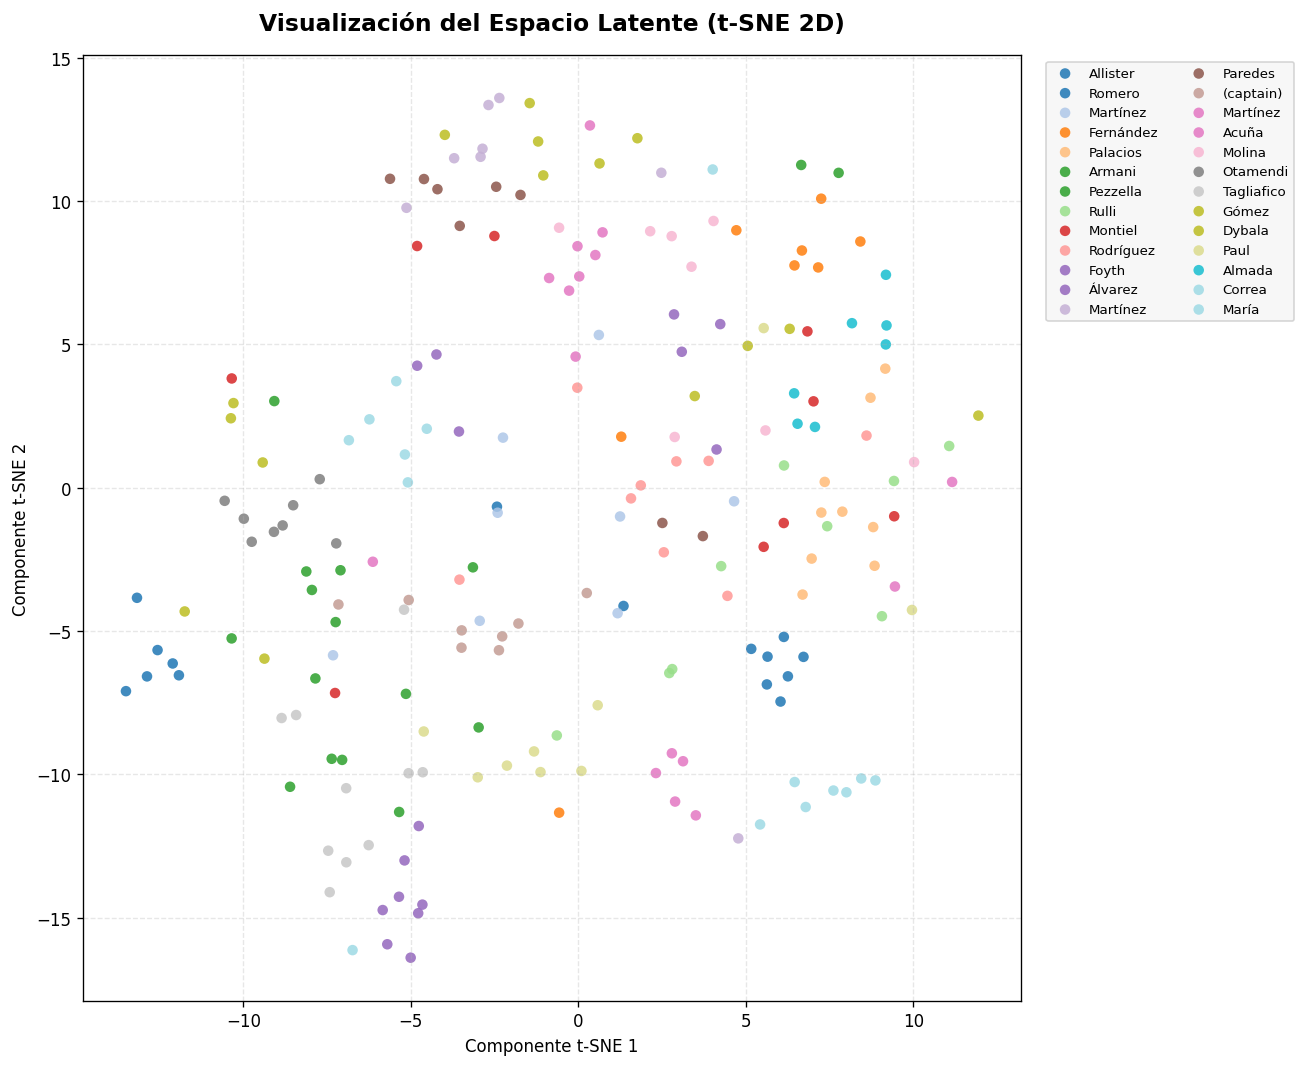

In [22]:
# ── Visualización t-SNE del espacio latente — modelo refinado final ───────
test_loader_final = build_dataloader(test_df)
plot_latent_space(final_model, test_loader_final, idx_to_label)


Errores en test: 102 / 210 (48.6%)


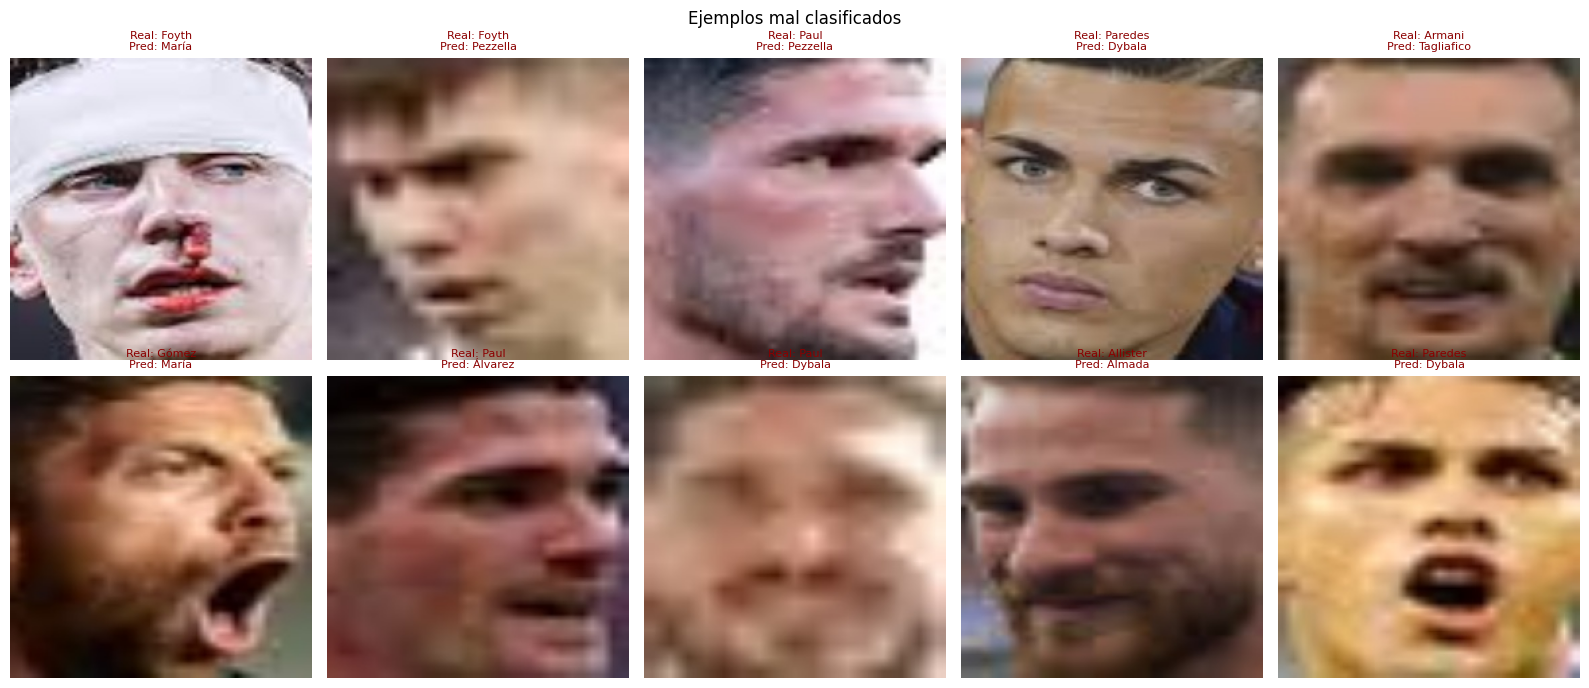

In [23]:
# ── Analisis de errores ──────────────────────────────────────

errors = [
    (path, true_l, pred_l)
    for path, true_l, pred_l in zip(test_df['image_path'].tolist(), all_true, all_preds)
    if true_l != pred_l
]

print(f'Errores en test: {len(errors)} / {len(test_df)} ({100*len(errors)/len(test_df):.1f}%)')

n_show = min(10, len(errors))
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, (img_path, true_l, pred_l) in zip(axes.flatten(), errors[:n_show]):
    try:
        img = Image.open(Path(FACES_DIR) / img_path).convert('RGB')
        ax.imshow(img)
    except Exception:
        ax.set_facecolor('#eee')
    real_name = idx_to_label[true_l].replace('_', ' ').split()[-1]
    pred_name = idx_to_label[pred_l].replace('_', ' ').split()[-1]
    ax.set_title(f'Real: {real_name}\nPred: {pred_name}', fontsize=8, color='darkred')
    ax.axis('off')

plt.suptitle('Ejemplos mal clasificados', fontsize=12)
plt.tight_layout()
plt.show()

---
## R4 — Extended Fine-tuning (20 épocas adicionales, LR más bajo)

Continúa entrenando el modelo R1 (ganador del refinamiento) con un learning rate
aún más conservador que en R1 (10× menor). Si R4 supera a R1 en mAP de validación,
R4 pasa a ser el modelo final. Si no mejora, R1 sigue siendo el modelo final.

| Parámetro | R1 | R4 |
|---|---|---|
| LR backbone | 1e-5 | 5e-6 |
| LR cabeza | 1e-4 | 5e-5 |
| Épocas | 15 | 20 |
| Scheduler | CosineAnnealing(T_max=15) | CosineAnnealing(T_max=20) |

In [24]:
# ── R4 — Extended Fine-tuning ─────────────────────────────────
import copy

set_seed()

# Parte siempre desde model_r1 (ganador del refinamiento)
model_r4 = copy.deepcopy(model_r1)

# Asegurarse de que todo el backbone esté descongelado
for param in model_r4.backbone.parameters():
    param.requires_grad = True

backbone_params_r4 = [p for p in model_r4.backbone.parameters() if p.requires_grad]
head_params_r4 = (
    list(model_r4.embedding_layer.parameters()) +
    list(model_r4.classifier_head.parameters())
)

# LR 10x menor que R1 para un ajuste más fino
optimizer_r4 = torch.optim.AdamW([
    {'params': backbone_params_r4, 'lr': 5e-6, 'weight_decay': 1e-4},
    {'params': head_params_r4,     'lr': 5e-5, 'weight_decay': 1e-4},
])
scheduler_r4 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_r4, T_max=150)

criterion_r4 = nn.CrossEntropyLoss(label_smoothing=0.1)

# DataLoaders con augmentaciones (igual que R1)
train_loader_r4      = build_dataloader(train_df, use_flip=True, use_color_jitter=True, shuffle=True)
train_eval_loader_r4 = build_dataloader(train_df, shuffle=False)
val_loader_r4        = build_dataloader(val_df)

model_r4, history_r4, best_map_r4 = run_experiment(
    'R4-ExtFineTune',
    model_r4, train_loader_r4, train_eval_loader_r4, val_loader_r4,
    criterion_r4, optimizer_r4, n_epochs=150,
    epoch_scheduler=scheduler_r4,
)
print(f'\nMejor mAP validacion R4: {best_map_r4:.4f}')

[R4-ExtFineTune] Ep 01/150 | Loss tr=3.5902 val=1.8200 | mAP=0.6493 Acc=0.5768 F1=0.5736
[R4-ExtFineTune] Ep 02/150 | Loss tr=3.4968 val=1.7944 | mAP=0.6625 Acc=0.5859 F1=0.5817
[R4-ExtFineTune] Ep 03/150 | Loss tr=3.4879 val=1.7749 | mAP=0.6576 Acc=0.5682 F1=0.5658
[R4-ExtFineTune] Ep 04/150 | Loss tr=3.4916 val=1.7419 | mAP=0.6653 Acc=0.5804 F1=0.5811
[R4-ExtFineTune] Ep 05/150 | Loss tr=3.4427 val=1.6893 | mAP=0.6757 Acc=0.5871 F1=0.5806
[R4-ExtFineTune] Ep 06/150 | Loss tr=3.3987 val=1.7180 | mAP=0.6808 Acc=0.5907 F1=0.5893
[R4-ExtFineTune] Ep 07/150 | Loss tr=3.3780 val=1.7108 | mAP=0.6773 Acc=0.5998 F1=0.5949
[R4-ExtFineTune] Ep 08/150 | Loss tr=3.3977 val=1.7508 | mAP=0.6758 Acc=0.5991 F1=0.5977
[R4-ExtFineTune] Ep 09/150 | Loss tr=3.3809 val=1.6704 | mAP=0.6834 Acc=0.6082 F1=0.6049
[R4-ExtFineTune] Ep 10/150 | Loss tr=3.3505 val=1.6827 | mAP=0.6772 Acc=0.6199 F1=0.6189
[R4-ExtFineTune] Ep 11/150 | Loss tr=3.3514 val=1.6939 | mAP=0.6793 Acc=0.6247 F1=0.6211
[R4-ExtFineTune] Ep 1

  Comparación R1 vs R4 (mAP en validación)
  R1 — Fine-tuning profundo (15 ep): 0.6488
  R4 — Extended fine-tuning (150 ep): 0.8029

✅  R4 MEJORA a R1 (0.8029 > 0.6488). Usando R4 como modelo final.


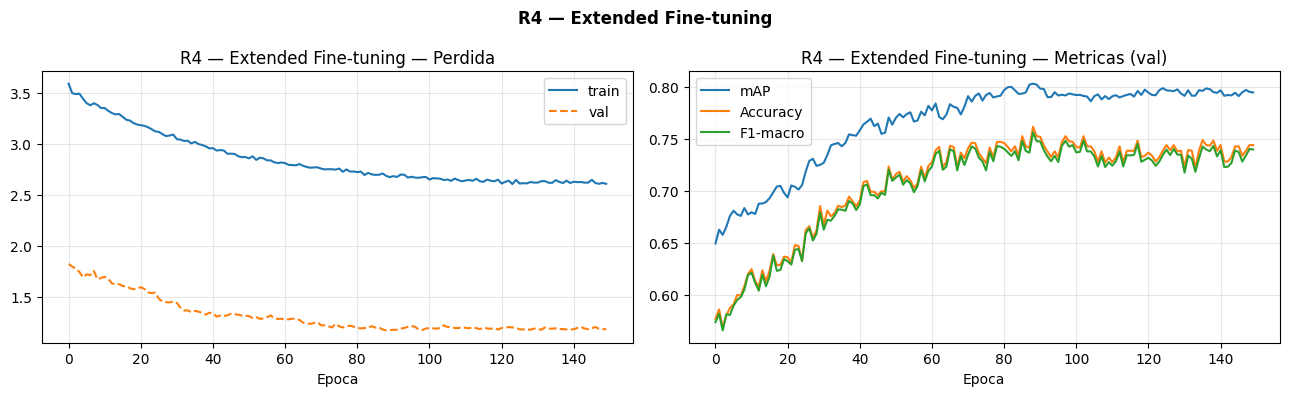

In [32]:
# ── Comparación R1 vs R4 y elección del modelo final ──────────
print('=' * 55)
print('  Comparación R1 vs R4 (mAP en validación)')
print('=' * 55)
print(f'  R1 — Fine-tuning profundo (15 ep): {best_map_r1:.4f}')
print(f'  R4 — Extended fine-tuning (150 ep): {best_map_r4:.4f}')
print('=' * 55)

if best_map_r4 > best_map_r1:
    final_model_extended = model_r4
    final_map_extended   = best_map_r4
    final_name_extended  = 'R4 — Extended Fine-tuning'
    print(f'\n✅  R4 MEJORA a R1 ({best_map_r4:.4f} > {best_map_r1:.4f}). Usando R4 como modelo final.')
else:
    final_model_extended = model_r1
    final_map_extended   = best_map_r1
    final_name_extended  = 'R1 — Fine-tuning profundo'
    print(f'\n⚠️  R4 NO mejora a R1 ({best_map_r4:.4f} ≤ {best_map_r1:.4f}). Manteniendo R1 como modelo final.')

plot_curves(history_r4, 'R4 — Extended Fine-tuning')

---
## 6.5. Evaluación final del Modelo Ganador Extendido (R4) en Test

Evaluación definitiva en el conjunto de test para el modelo final seleccionado (`final_model_extended`). Esto incluye las métricas principales (mAP, Accuracy, F1-score), la matriz de confusión, la visualización t-SNE de su espacio latente y el análisis de errores.

In [26]:
# ── 6.5.1. Métricas finales en test para R4 ───────────────────
test_loader = build_dataloader(test_df)
train_eval_loader_save = build_dataloader(train_df, shuffle=False)
final_centroids_save = compute_class_centroids(final_model_extended, train_eval_loader_save)

test_metrics = make_metrics()
_, test_m_extended = evaluate_triplet(final_model_extended, test_loader, final_centroids_save, test_metrics)

print(f"\n{'='*45}")
print(f'  Métricas finales en TEST — {final_name_extended}')
print(f"{'='*45}")
print(f"  mAP (macro)  : {test_m_extended['map']:.4f}")
print(f"  Accuracy     : {test_m_extended['acc']:.4f}")
print(f"  F1 (macro)   : {test_m_extended['f1']:.4f}")
print(f"{'='*45}")


  Métricas finales en TEST — R4 — Extended Fine-tuning
  mAP (macro)  : 0.8693
  Accuracy     : 0.7760
  F1 (macro)   : 0.7749


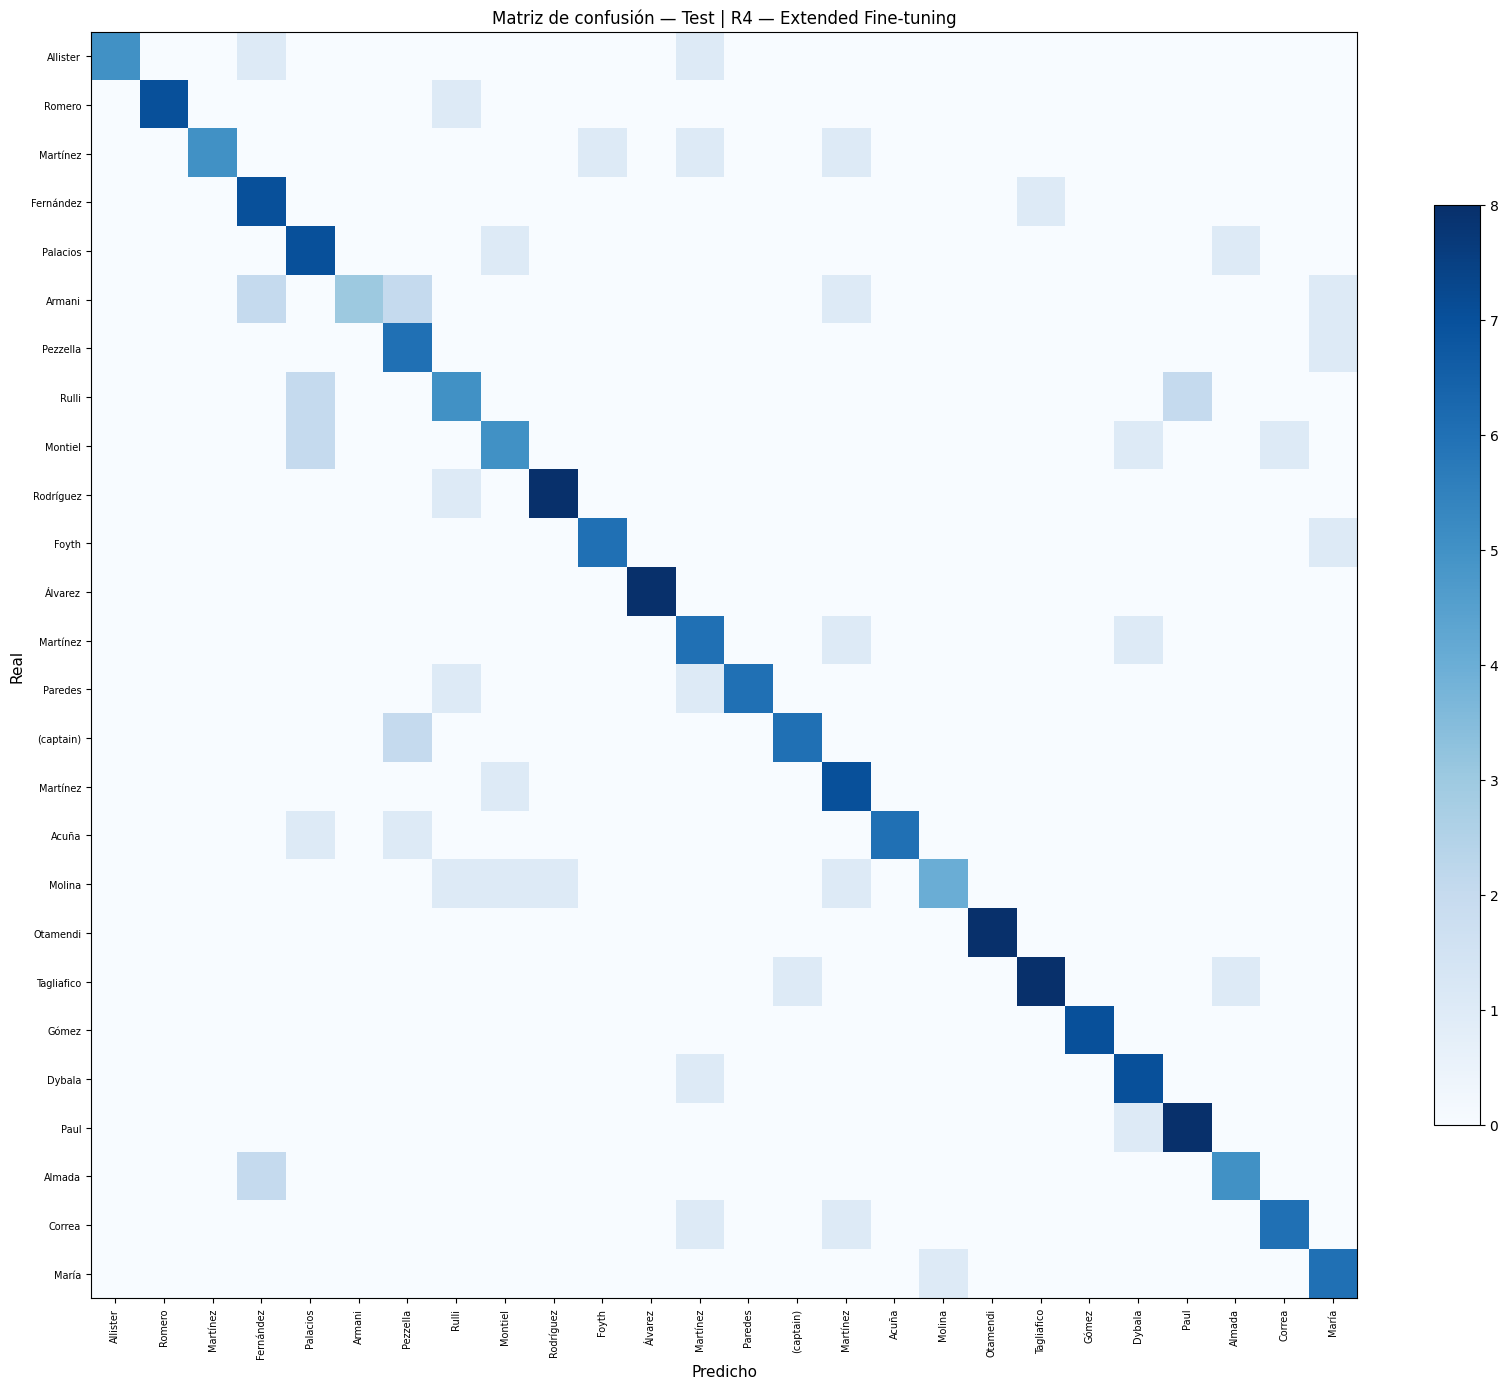


Peores 5 clases (accuracy por clase):
  Franco Armani                  33.33%
  Nahuel Molina                  50.00%
  Gerónimo Rulli                 55.56%
  Gonzalo Montiel                55.56%
  Emiliano Martínez              62.50%


In [27]:
# ── 6.5.2. Matriz de confusión para R4 ───────────────────────
cm_metric_ext = MulticlassConfusionMatrix(num_classes=NUM_CLASSES).to(DEVICE)
all_preds_ext = []
all_true_ext  = []

final_model_extended.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        embeddings, _ = final_model_extended(imgs)
        similarities = torch.matmul(embeddings, final_centroids_save.to(DEVICE).t())
        logits = similarities * 10.0
        cm_metric_ext.update(torch.softmax(logits, 1), labels)
        all_preds_ext.extend(logits.argmax(1).cpu().numpy())
        all_true_ext.extend(labels.cpu().numpy())

cm_ext = cm_metric_ext.compute().cpu().numpy()
class_names = [idx_to_label[i].replace('_', ' ').split()[-1] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(cm_ext, cmap='Blues')
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(class_names, rotation=90, fontsize=7)
ax.set_yticklabels(class_names, fontsize=7)
ax.set_xlabel('Predicho', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
ax.set_title(f'Matriz de confusión — Test | {final_name_extended}', fontsize=12)
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

# Peores 5 clases
per_class_acc_ext = cm_ext.diagonal() / cm_ext.sum(axis=1).clip(min=1)
worst_5_ext = sorted(enumerate(per_class_acc_ext), key=lambda x: x[1])[:5]
print('\nPeores 5 clases (accuracy por clase):')
for idx, acc in worst_5_ext:
    print(f'  {idx_to_label[idx]:<30} {acc:.2%}')

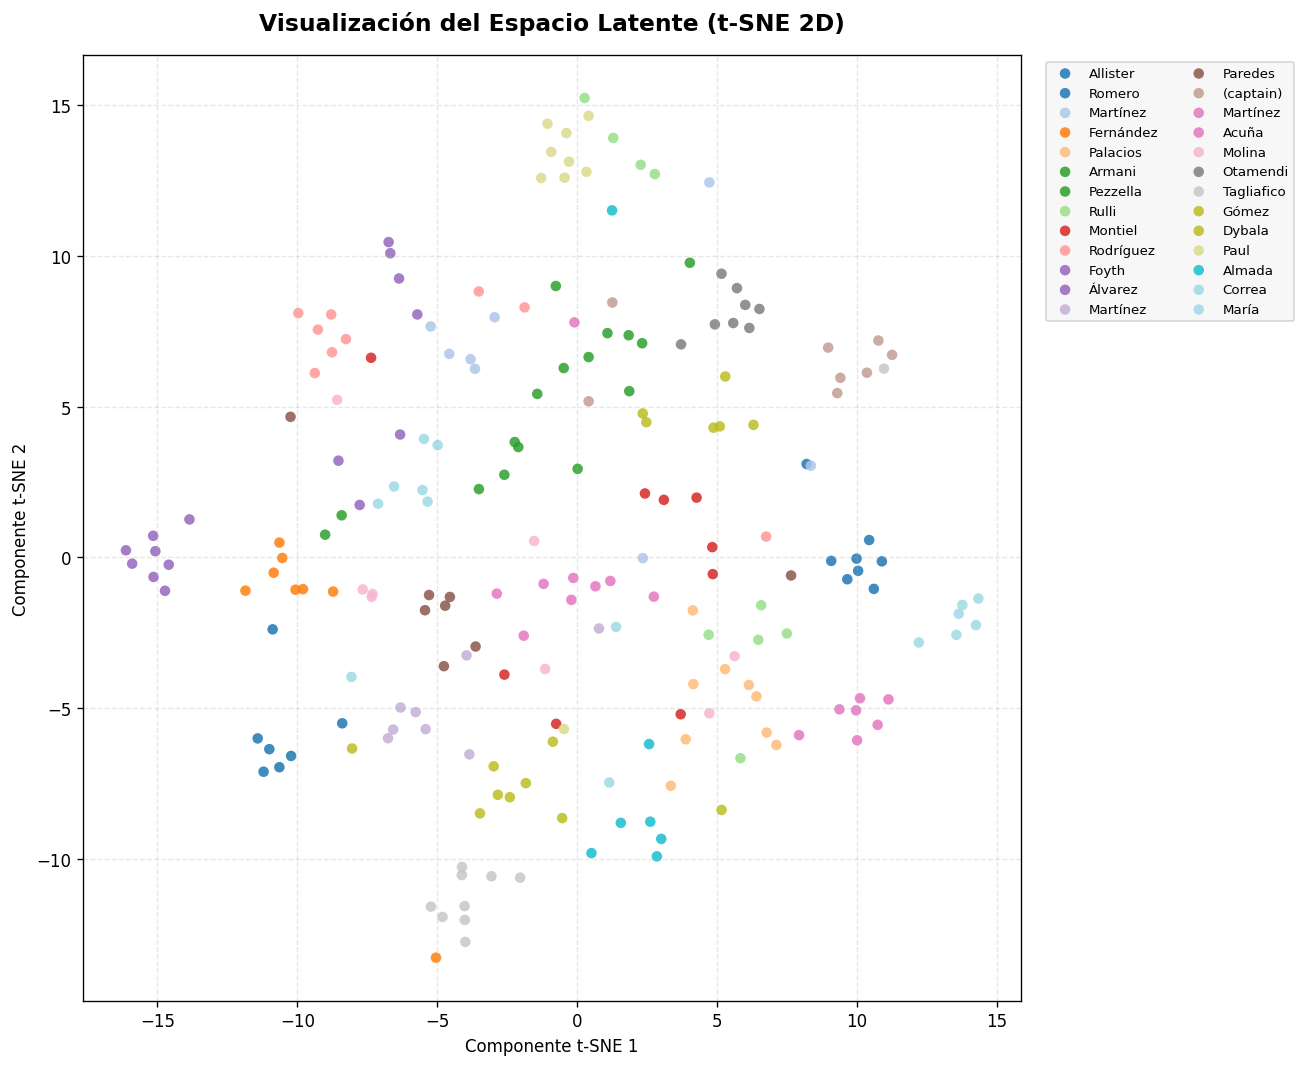

In [28]:
# ── 6.5.3. Visualización t-SNE de R4 en test ─────────────────
plot_latent_space(final_model_extended, test_loader, idx_to_label)

Errores en test: 48 / 210 (22.9%)


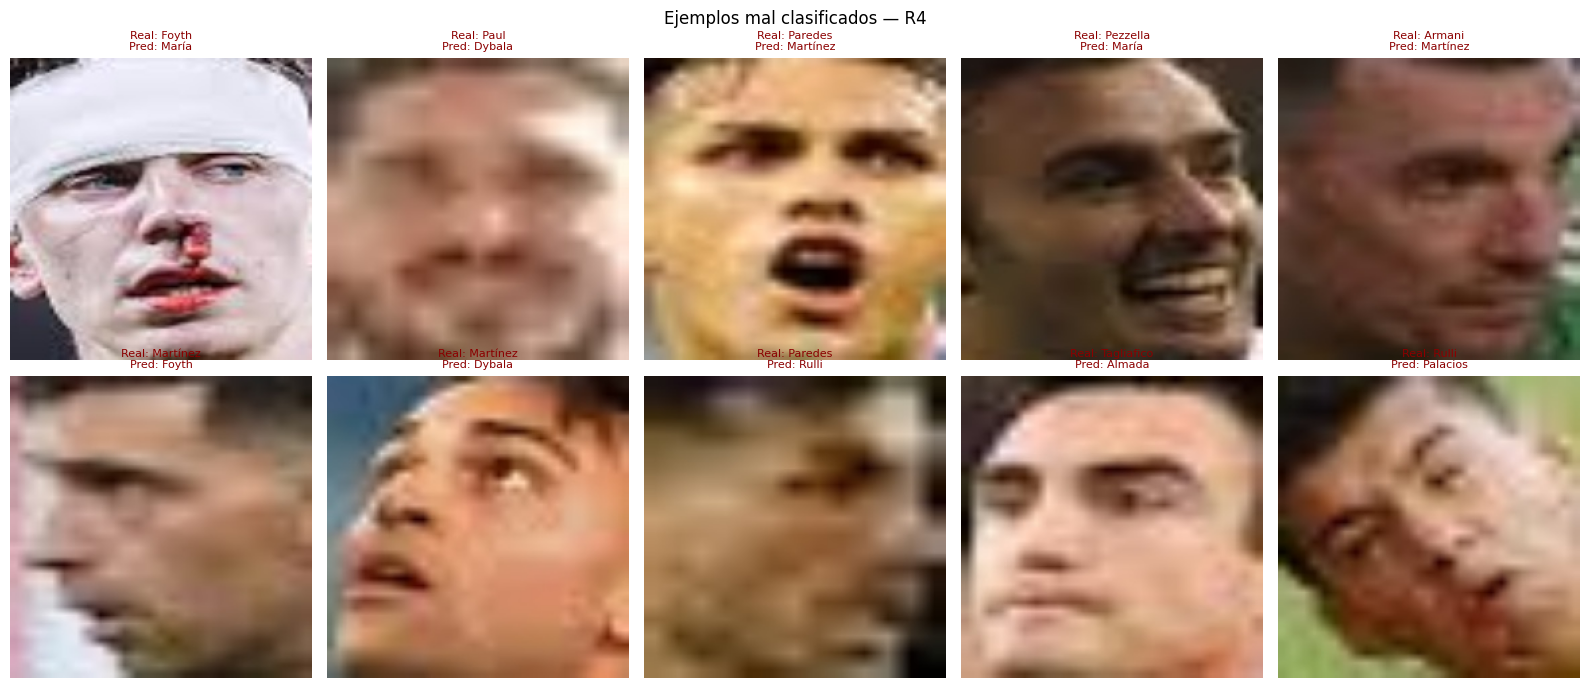

In [29]:
# ── 6.5.4. Análisis de errores en R4 ─────────────────────────
errors_ext = [
    (path, true_l, pred_l)
    for path, true_l, pred_l in zip(test_df['image_path'].tolist(), all_true_ext, all_preds_ext)
    if true_l != pred_l
]

print(f'Errores en test: {len(errors_ext)} / {len(test_df)} ({100*len(errors_ext)/len(test_df):.1f}%)')

n_show = min(10, len(errors_ext))
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, (img_path, true_l, pred_l) in zip(axes.flatten(), errors_ext[:n_show]):
    try:
        img = Image.open(Path(FACES_DIR) / img_path).convert('RGB')
        ax.imshow(img)
    except Exception:
        ax.set_facecolor('#eee')
    real_name = idx_to_label[true_l].replace('_', ' ').split()[-1]
    pred_name = idx_to_label[pred_l].replace('_', ' ').split()[-1]
    ax.set_title(f'Real: {real_name}\nPred: {pred_name}', fontsize=8, color='darkred')
    ax.axis('off')

plt.suptitle('Ejemplos mal clasificados — R4', fontsize=12)
plt.tight_layout()
plt.show()

---
## 7. Guardado del modelo

Se guarda un **checkpoint único** (`modelo.pth`) con todo lo necesario para inferencia
en producción (Semana 4) sin necesidad de tener el dataset de train disponible:

| Clave | Contenido |
|---|---|
| `model_state_dict` | Pesos del modelo (backbone + embedding + classifier) |
| `centroids` | Tensor [26, 128] — centroide normalizado de cada jugador |
| `idx_to_label` | dict int → nombre del jugador |
| `embedding_dim` | 128 |
| `num_classes` | 26 |

In [30]:
# ── 7. Guardado del modelo ────────────────────────────────────
from pathlib import Path

# Modelo final: el mejor entre R1 y R4
# (si no se ejecutó R4, usar final_model del torneo de refinamiento)
try:
    save_model = final_model_extended
    save_name  = final_name_extended
except NameError:
    # R4 no fue ejecutado; usar el ganador del refinamiento original
    save_model = final_model
    save_name  = best_refine_name

# Calcular centroides finales sobre el conjunto de entrenamiento
print(f'Calculando centroides del modelo: {save_name} ...')
train_eval_loader_save = build_dataloader(train_df, shuffle=False)
final_centroids_save = compute_class_centroids(save_model, train_eval_loader_save)

# Construir el checkpoint unificado
checkpoint = {
    'model_state_dict': save_model.state_dict(),
    'centroids':        final_centroids_save.cpu(),
    'idx_to_label':     idx_to_label,
    'embedding_dim':    128,
    'num_classes':      NUM_CLASSES,
}

# Ruta de guardado (dentro de dev/, compatible con local y Colab)
if IN_COLAB:
    save_dir = Path('/content/dev')
else:
    save_dir = Path('../dev')
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / 'modelo.pth'

torch.save(checkpoint, save_path)

size_mb = save_path.stat().st_size / 1024 ** 2
print(f'\nModelo guardado: {save_path}  ({size_mb:.1f} MB)')
print(f'  Modelo usado: {save_name}')
print(f'  Keys del checkpoint: {list(checkpoint.keys())}')
print(f'  centroids shape: {checkpoint["centroids"].shape}')
print(f'  num clases: {checkpoint["num_classes"]}')

if size_mb > 95:
    print('\nAdvertencia: supera 95 MB. Configurar Git LFS antes de commitear:')
    print('  git lfs install')
    print("  git lfs track 'dev/*.pth'")
    print('  git add .gitattributes dev/modelo.pth')
else:
    print('\nTamano OK para GitHub sin Git LFS.')

# Descargar a local (descomentar si se desea)
# from google.colab import files
# files.download(str(save_path))

Calculando centroides del modelo: R4 — Extended Fine-tuning ...

Modelo guardado: ..\dev\modelo.pth  (107.1 MB)
  Modelo usado: R4 — Extended Fine-tuning
  Keys del checkpoint: ['model_state_dict', 'centroids', 'idx_to_label', 'embedding_dim', 'num_classes']
  centroids shape: torch.Size([26, 128])
  num clases: 26

Advertencia: supera 95 MB. Configurar Git LFS antes de commitear:
  git lfs install
  git lfs track 'dev/*.pth'
  git add .gitattributes dev/modelo.pth


In [31]:
# ── Verificación del checkpoint ───────────────────────────────
ckpt = torch.load(save_path, map_location='cpu', weights_only=False)

print('Checkpoint cargado correctamente.')
print(f'  Keys: {list(ckpt.keys())}')
print(f'  centroids shape: {ckpt["centroids"].shape}')
print(f'  num_classes: {ckpt["num_classes"]}')
print(f'  embedding_dim: {ckpt["embedding_dim"]}')
print(f'  Primeros 5 jugadores: {list(ckpt["idx_to_label"].values())[:5]}')
print(f'  Tensores en state_dict: {len(ckpt["model_state_dict"])}')


Checkpoint cargado correctamente.
  Keys: ['model_state_dict', 'centroids', 'idx_to_label', 'embedding_dim', 'num_classes']
  centroids shape: torch.Size([26, 128])
  num_classes: 26
  embedding_dim: 128
  Primeros 5 jugadores: ['Alexis Mac Allister', 'Cristian Romero', 'Emiliano Martínez', 'Enzo Fernández', 'Exequiel Palacios']
  Tensores en state_dict: 720
